# Importing Libraries:

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model    import LinearRegression, LogisticRegression
from sklearn.cluster         import KMeans
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, KFold
from sklearn.metrics         import (
    mean_squared_error, r2_score,
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay,
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
})
RANDOM_STATE = 42


# Data Loading:

In [3]:
DATA_DIR = "./Data"

year_map = {
    "Election2008.csv": 2008,
    "Election2013.csv": 2013,
    "Election2017.csv": 2017,
    "Election2022.csv": 2022,
}

frames = []
for file_name, year in year_map.items():
    path = os.path.join(DATA_DIR, file_name)
    df_temp = pd.read_csv(path)
    df_temp.columns = df_temp.columns.str.strip().str.lower().str.replace(" ", "_")
    df_temp["year"] = year
    print(f"Loaded {file_name:25s} → {df_temp.shape[0]} rows")
    frames.append(df_temp)

election_df = pd.concat(frames, ignore_index=True)
print(f"\nCombined shape : {election_df.shape}")
print(f"Columns        : {list(election_df.columns)}")
election_df.head(8)

Loaded Election2008.csv          → 15 rows
Loaded Election2013.csv          → 21 rows
Loaded Election2017.csv          → 9 rows
Loaded Election2022.csv          → 13 rows

Combined shape : (58, 3)
Columns        : ['political_group', 'total', 'year']


,political_group,total,year
0,Communist Party of Nepal (Maoists),220,2008
1,Nepali Congress (NC),110,2008
2,Communist Party of Nepal (UML),103,2008
3,Madhesi People's Rights Forum Nepal,52,2008
4,Tarai Madhes Loktantrik Party,20,2008
5,Others,19,2008
6,Nepal Goodwill Party (Sadhvawana),9,2008
7,Communist Party of Nepal (Marxist Leninist),8,2008


In [4]:
print("Shape :", election_df.shape)
print("Years :", sorted(election_df["year"].unique()))
print("\nMissing values:")
print(election_df.isnull().sum())
print()
election_df.describe()

Shape : (58, 3)
Years : [np.int64(2008), np.int64(2013), np.int64(2017), np.int64(2022)]

Missing values:
political_group    0
total              0
year               0
dtype: int64



,total,year
count,58.000000,58.000000
mean,29.120690,2014.344828
std,49.632006,5.073328
min,1.000000,2008.000000
25%,3.000000,2009.250000
50%,7.500000,2013.000000
75%,20.000000,2017.000000
max,220.000000,2022.000000


# Exploratory Data Analysis

- Seats by Party per Election Year

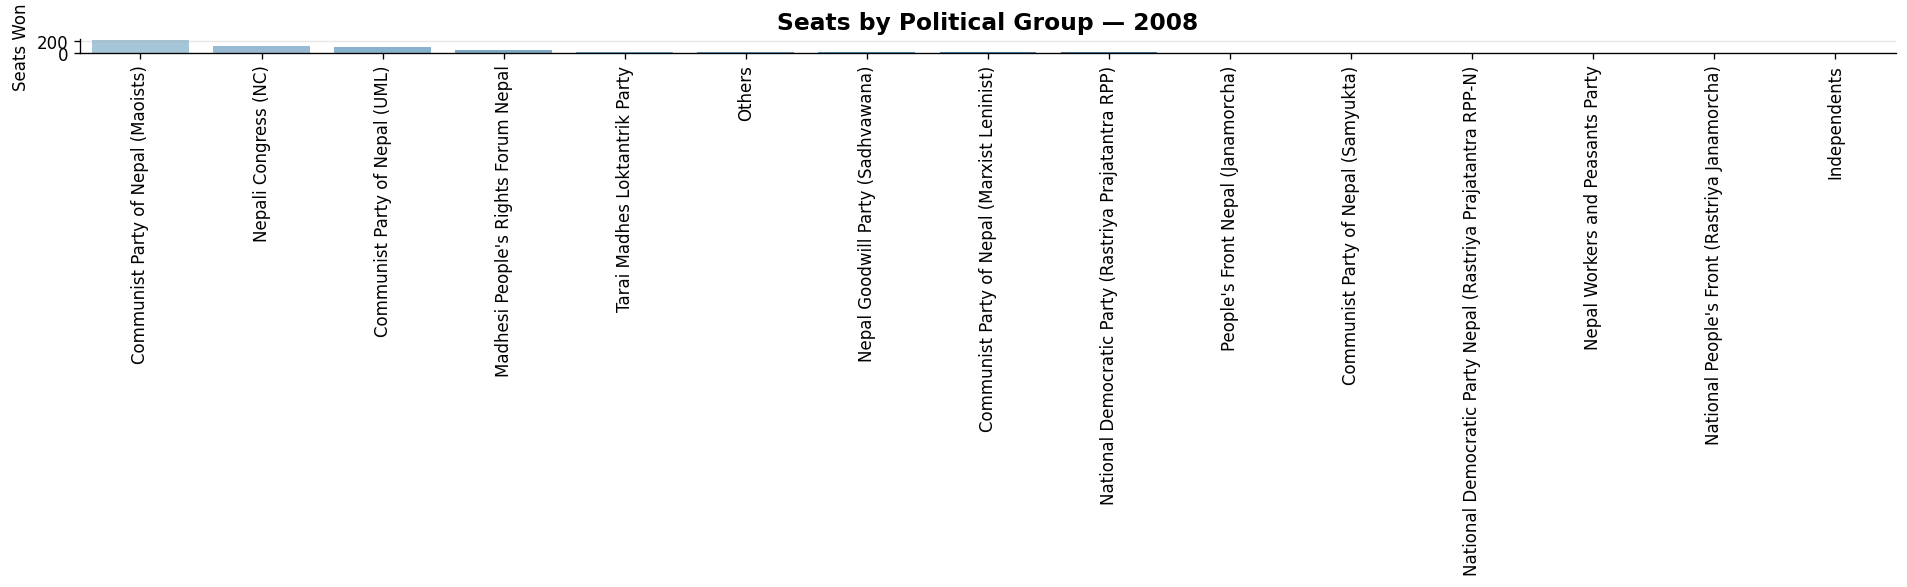

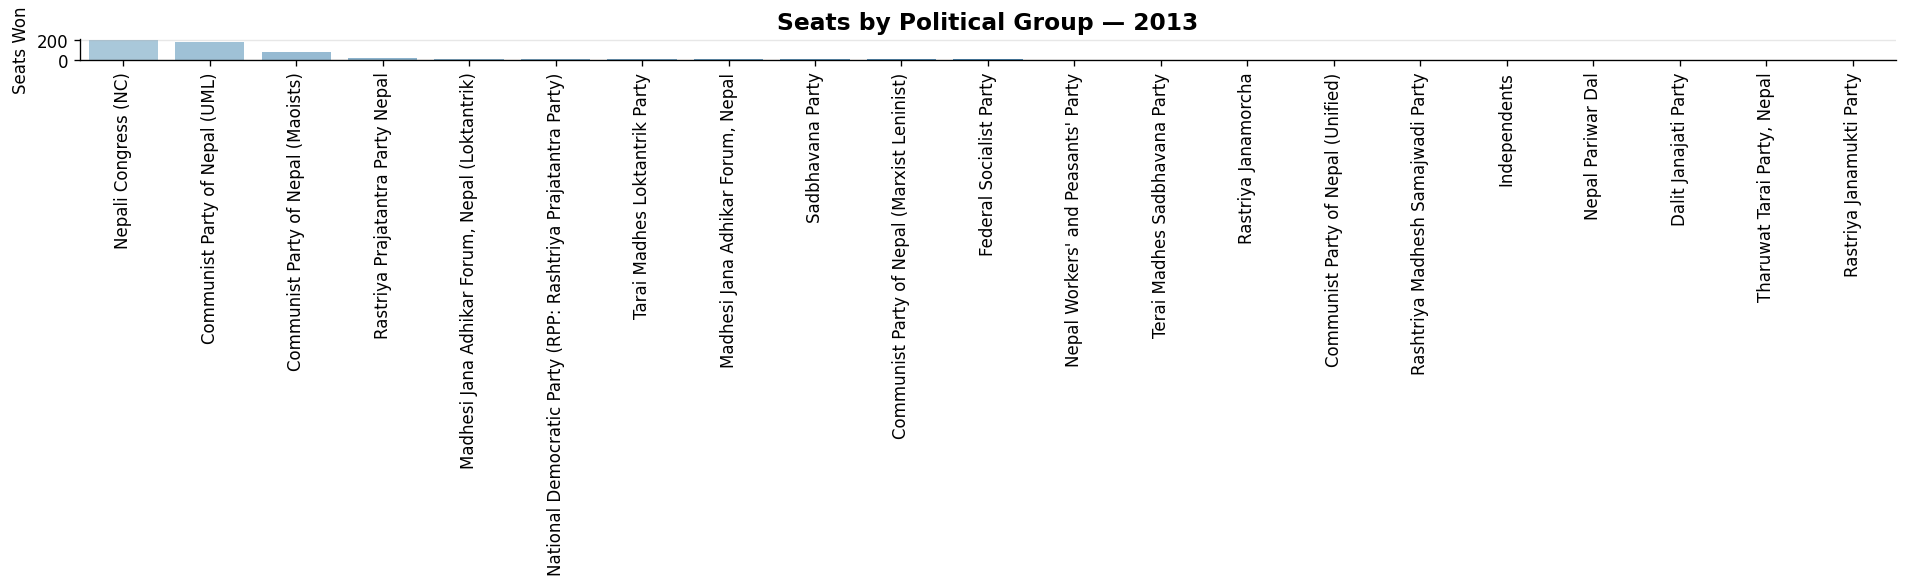

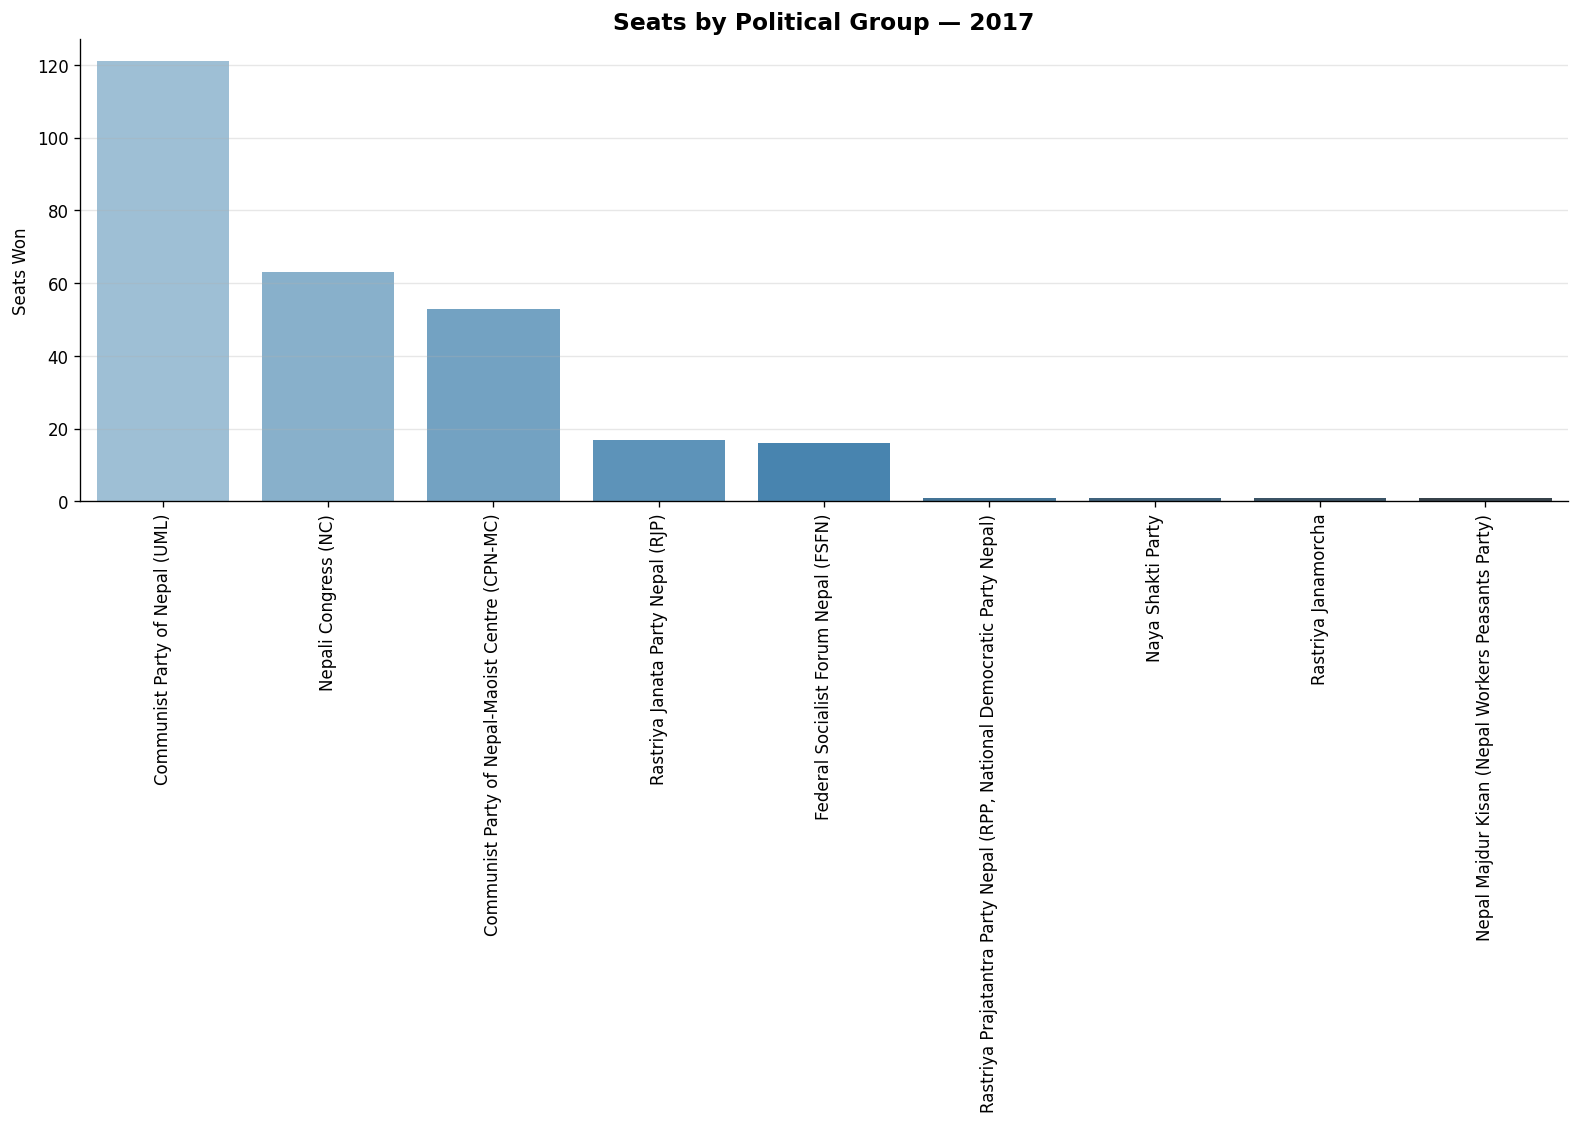

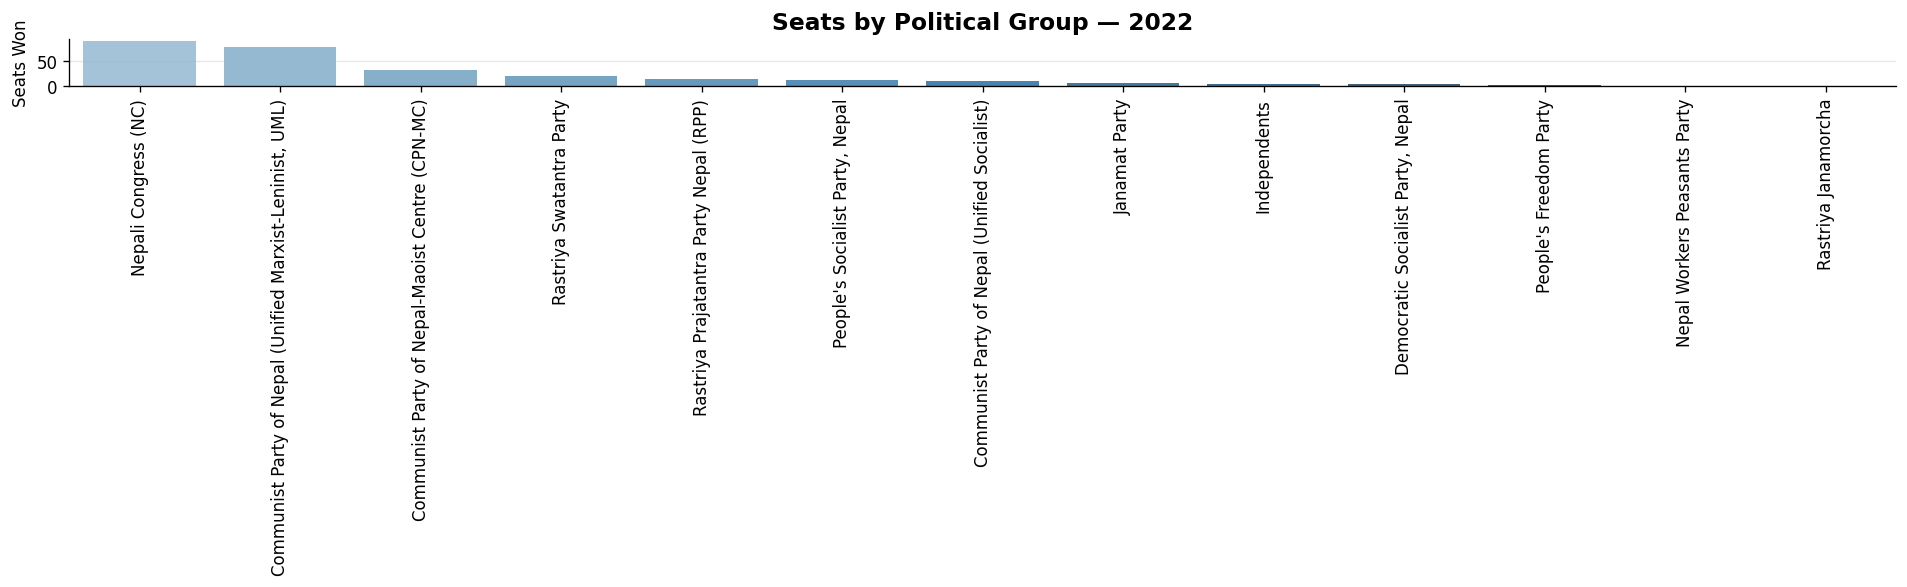

In [5]:
def plot_seats_by_year(df, year):
    df_year = df[df["year"] == year].sort_values("total", ascending=False)
    fig, ax = plt.subplots(figsize=(16, 5))
    sns.barplot(data=df_year, x="political_group", y="total", ax=ax, palette="Blues_d")
    ax.set_title(f"Seats by Political Group — {year}", fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Seats Won")
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()
    plt.show()

for yr in [2008, 2013, 2017, 2022]:
    plot_seats_by_year(election_df, yr)


- Bubble Chart for All Elections

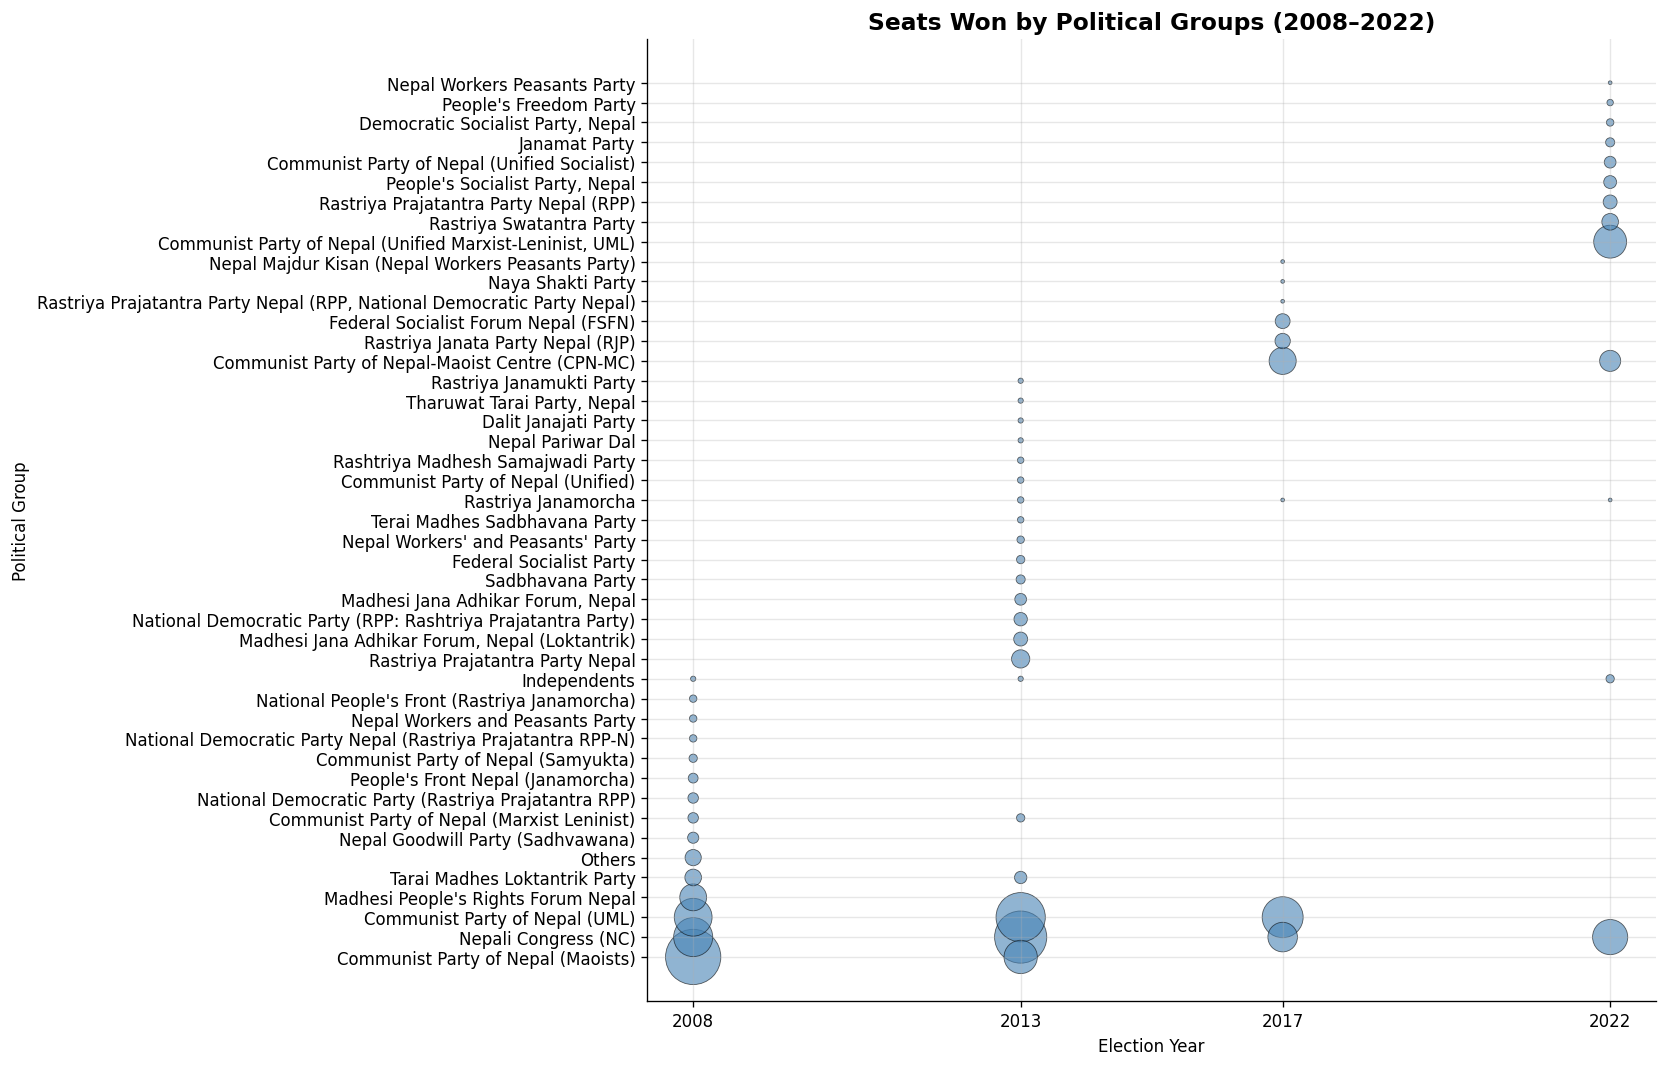

In [6]:
fig, ax = plt.subplots(figsize=(14, 9))
ax.scatter(
    election_df["year"], election_df["political_group"],
    s=election_df["total"] * 5, alpha=0.6,
    color="steelblue", edgecolors="black", linewidths=0.5,
)
ax.set_title("Seats Won by Political Groups (2008–2022)", fontsize=14, fontweight="bold")
ax.set_xlabel("Election Year"); ax.set_ylabel("Political Group")
ax.set_xticks([2008, 2013, 2017, 2022])
plt.tight_layout(); plt.show()

# Top 3 Parties — Trend Lines:
Before proceeding with data, there have been normalised variant party names before plotting so the same entity's results are joined correctly across years.

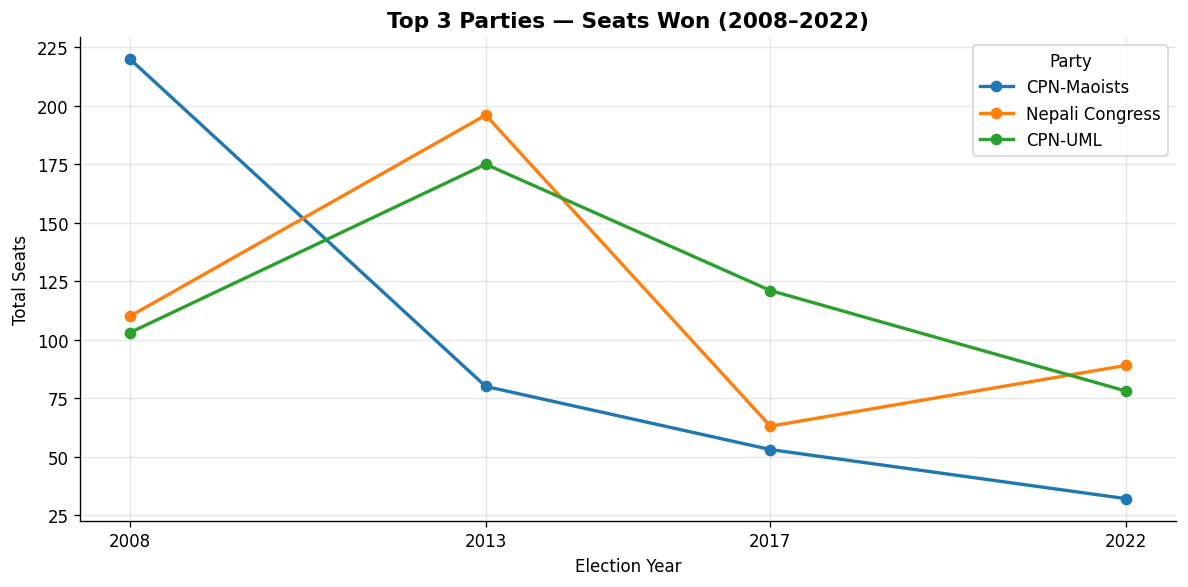

In [7]:
name_map = {
    "Communist Party of Nepal (Maoists)"                         : "CPN-Maoists",
    "Communist Party of Nepal-Maoist Centre (CPN-MC)"           : "CPN-Maoists",
    "Nepali Congress (NC)"                                        : "Nepali Congress",
    "Communist Party of Nepal (UML)"                             : "CPN-UML",
    "Communist Party of Nepal (Unified Marxist-Leninist, UML)"  : "CPN-UML",
}
election_df["party_clean"] = election_df["political_group"].replace(name_map)

TOP_THREE = ["CPN-Maoists", "Nepali Congress", "CPN-UML"]
trend = (
    election_df[election_df["party_clean"].isin(TOP_THREE)]
    .groupby(["year", "party_clean"])["total"].sum()
    .reset_index()
    .pivot(index="year", columns="party_clean", values="total")
)

fig, ax = plt.subplots(figsize=(10, 5))
for party in TOP_THREE:
    if party in trend.columns:
        ax.plot(trend.index, trend[party], marker="o", label=party, linewidth=2)
ax.set_title("Top 3 Parties — Seats Won (2008–2022)", fontsize=13, fontweight="bold")
ax.set_xlabel("Election Year"); ax.set_ylabel("Total Seats")
ax.set_xticks([2008, 2013, 2017, 2022]); ax.legend(title="Party")
plt.tight_layout(); plt.show()


# Feature Engineering

In [8]:

election_df = election_df.sort_values(["party_clean", "year"])
election_df["prev_total"] = election_df.groupby("party_clean")["total"].shift(1)

# Binary popularity label (per-fold inside cross-validation for the classifier)
avg_seats = election_df.groupby("year")["total"].transform("mean")
election_df["popular"] = (election_df["total"] > avg_seats).astype(int)

# Dropping rows with no previous data 
ml_df = election_df.dropna(subset=["prev_total"]).copy().reset_index(drop=True)

# Encode parties — fit on ALL parties so every fold has consistent integer IDs.
le = LabelEncoder()
ml_df["party_encoded"] = le.fit_transform(ml_df["party_clean"])

print(f"ML-ready rows : {len(ml_df)}")
print(f"\nPopularity distribution:")
print(ml_df["popular"].value_counts().rename({1: "Popular (1)", 0: "Not Popular (0)"}))
ml_df[["party_clean", "year", "total", "prev_total", "popular"]].head(10)


ML-ready rows : 15

Popularity distribution:
popular
Popular (1)        9
Not Popular (0)    6
Name: count, dtype: int64


,party_clean,year,total,prev_total,popular
0,CPN-Maoists,2013,80,220.0,1
1,CPN-Maoists,2017,53,80.0,1
2,CPN-Maoists,2022,32,53.0,1
3,CPN-UML,2013,175,103.0,1
4,CPN-UML,2017,121,175.0,1
5,CPN-UML,2022,78,121.0,1
6,Communist Party of Nepal (Marxist Leninist),2013,5,8.0,0
7,Independents,2013,2,2.0,0
8,Independents,2022,5,2.0,0
9,Nepali Congress,2013,196,110.0,1


# Modeling:
- Linear Regression Models
- Logistics Regression Moddels 
- KNN-clustering Models

# Linear Regression Models to Predict wining seats

In [11]:
FEATURES_REG = ["party_encoded", "year", "prev_total"]
TARGET_REG   = "total"

X_reg = ml_df[FEATURES_REG].values
y_reg = ml_df[TARGET_REG].values

# Cross-validation
reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LinearRegression()),
])

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_rmse = np.sqrt(-cross_val_score(
    reg_pipeline, X_reg, y_reg,
    scoring="neg_mean_squared_error", cv=kf))

cv_r2 = cross_val_score(
    reg_pipeline, X_reg, y_reg,
    scoring="r2", cv=kf)

print("Cross-Validation: Linear Regression: ")
print(f"  RMSE  : {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f} seats")
print(f"  R²    : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")


# Hold-out split for visual diagnostics 
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

reg_pipeline.fit(X_train_r, y_train_r)
y_pred_r = reg_pipeline.predict(X_test_r)

holdout_rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
holdout_r2   = r2_score(y_test_r, y_pred_r)
print(f"Hold-out (20%)")
print(f"  RMSE : {holdout_rmse:.2f} seats")
print(f"  R²   : {holdout_r2:.3f}")


Cross-Validation: Linear Regression: 
  RMSE  : 51.35 ± 29.85 seats
  R²    : -0.572 ± 1.152
Hold-out (20%)
  RMSE : 95.56 seats
  R²   : -2.289


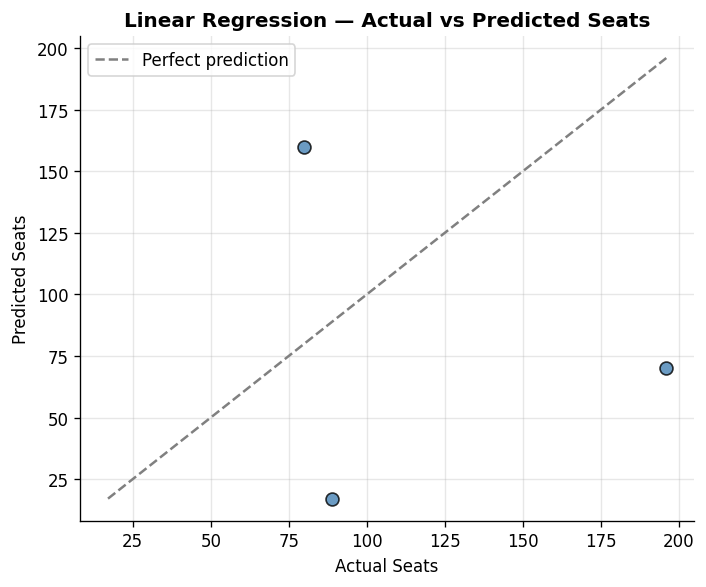

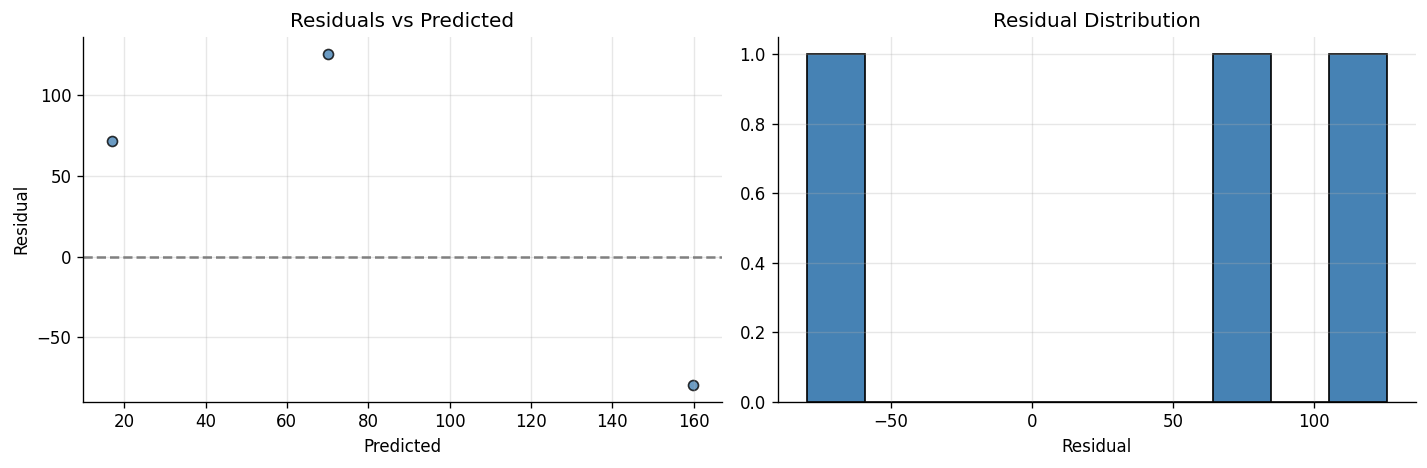

In [12]:
# Actual vs Predicted
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_test_r, y_pred_r, color="steelblue", edgecolors="black", alpha=0.8, s=60)
lo, hi = min(y_test_r.min(), y_pred_r.min()), max(y_test_r.max(), y_pred_r.max())
ax.plot([lo, hi], [lo, hi], "--", color="gray", label="Perfect prediction")
ax.set_title("Linear Regression — Actual vs Predicted Seats", fontweight="bold")
ax.set_xlabel("Actual Seats"); ax.set_ylabel("Predicted Seats")
ax.legend(); plt.tight_layout(); plt.show()

# Residuals
residuals = y_test_r - y_pred_r
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred_r, residuals, color="steelblue", edgecolors="black", alpha=0.8)
axes[0].axhline(0, color="gray", linestyle="--")
axes[0].set_title("Residuals vs Predicted"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Residual")
axes[1].hist(residuals, bins=10, color="steelblue", edgecolor="black")
axes[1].set_title("Residual Distribution"); axes[1].set_xlabel("Residual")
plt.tight_layout(); plt.show()


# Logistic Regression for Predicting Popularity

In [14]:
FEATURES_CLF = ["party_encoded", "year", "prev_total"]
TARGET_CLF   = "popular"

X_clf = ml_df[FEATURES_CLF].values
y_clf = ml_df[TARGET_CLF].values

clf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_acc = cross_val_score(clf_pipeline, X_clf, y_clf, scoring="accuracy",  cv=skf)
cv_auc = cross_val_score(clf_pipeline, X_clf, y_clf, scoring="roc_auc",   cv=skf)
cv_f1  = cross_val_score(clf_pipeline, X_clf, y_clf, scoring="f1_weighted", cv=skf)

print("Stratified CV: Logistic Regression")
print(f"  Accuracy : {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")
print(f"  ROC-AUC  : {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print(f"  F1 (wtd) : {cv_f1.mean():.3f} ± {cv_f1.std():.3f}")


Stratified CV: Logistic Regression
  Accuracy : 0.933 ± 0.133
  ROC-AUC  : 0.900 ± 0.200
  F1 (wtd) : 0.933 ± 0.133


── Hold-out Classification Report ──
              precision    recall  f1-score   support

 Not Popular       1.00      1.00      1.00         1
     Popular       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



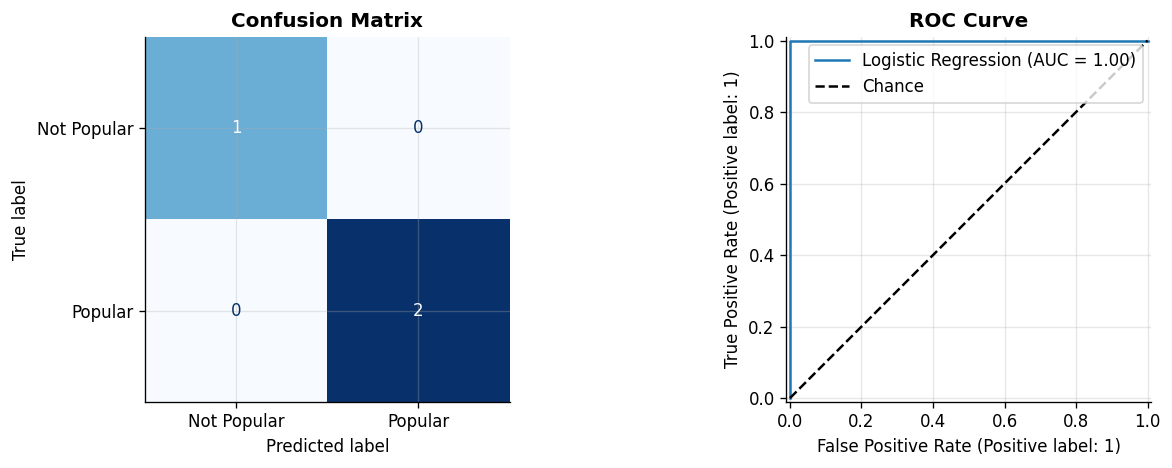


Hold-out ROC-AUC : 1.000
Hold-out Accuracy : 1.000


In [15]:
# Hold-out for confusion matrix & ROC curve
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)

clf_pipeline.fit(X_train_c, y_train_c)
y_pred_c  = clf_pipeline.predict(X_test_c)
y_prob_c  = clf_pipeline.predict_proba(X_test_c)[:, 1]

print("── Hold-out Classification Report ──")
print(classification_report(y_test_c, y_pred_c,
      target_names=["Not Popular", "Popular"], zero_division=0))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test_c, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Popular", "Popular"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontweight="bold")

# ROC curve
RocCurveDisplay.from_predictions(y_test_c, y_prob_c, ax=axes[1], name="Logistic Regression")
axes[1].plot([0,1],[0,1],"k--", label="Chance"); axes[1].legend()
axes[1].set_title("ROC Curve", fontweight="bold")

plt.tight_layout(); plt.show()

print(f"\nHold-out ROC-AUC : {roc_auc_score(y_test_c, y_prob_c):.3f}")
print(f"Hold-out Accuracy : {accuracy_score(y_test_c, y_pred_c):.3f}")


# K-Means Clustering for Performance Analysis on Group Parties 

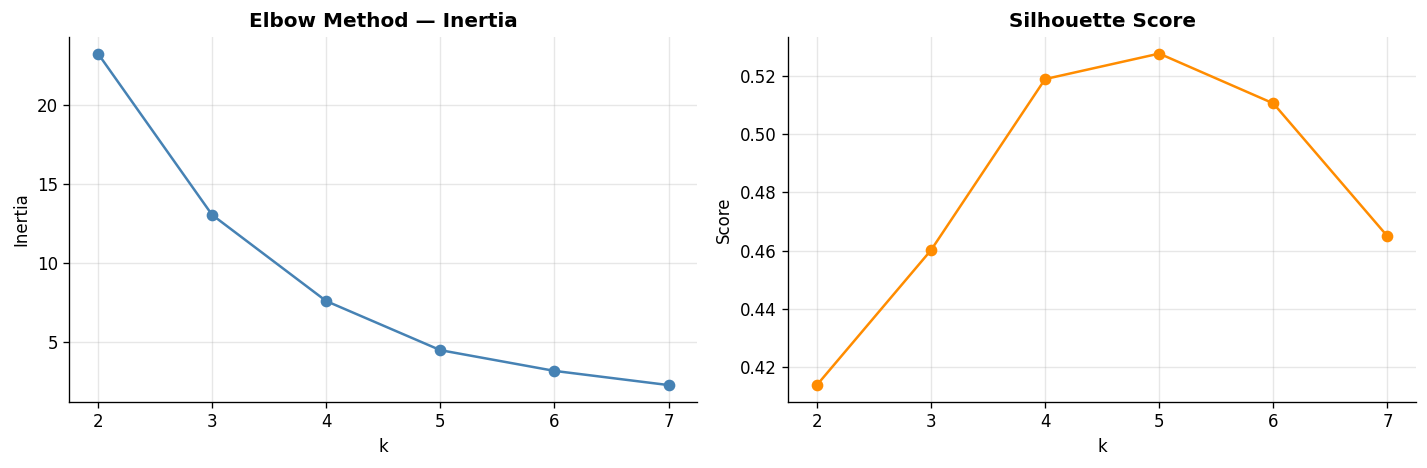

Best k by silhouette: 5  (score = 0.528)


In [16]:
from sklearn.metrics import silhouette_score

cluster_features = ml_df[["total", "year", "prev_total"]].copy()
scaler_k = StandardScaler()
X_scaled = scaler_k.fit_transform(cluster_features)

# Elbow + Silhouette to justify k
inertias, silhouettes = [], []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker="o", color="steelblue")
axes[0].set_title("Elbow Method — Inertia", fontweight="bold")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(K_range, silhouettes, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score", fontweight="bold")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout(); plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"Best k by silhouette: {best_k}  (score = {max(silhouettes):.3f})")


Silhouette score (k=3): 0.460  — higher is better; >0.3 is reasonable for small data


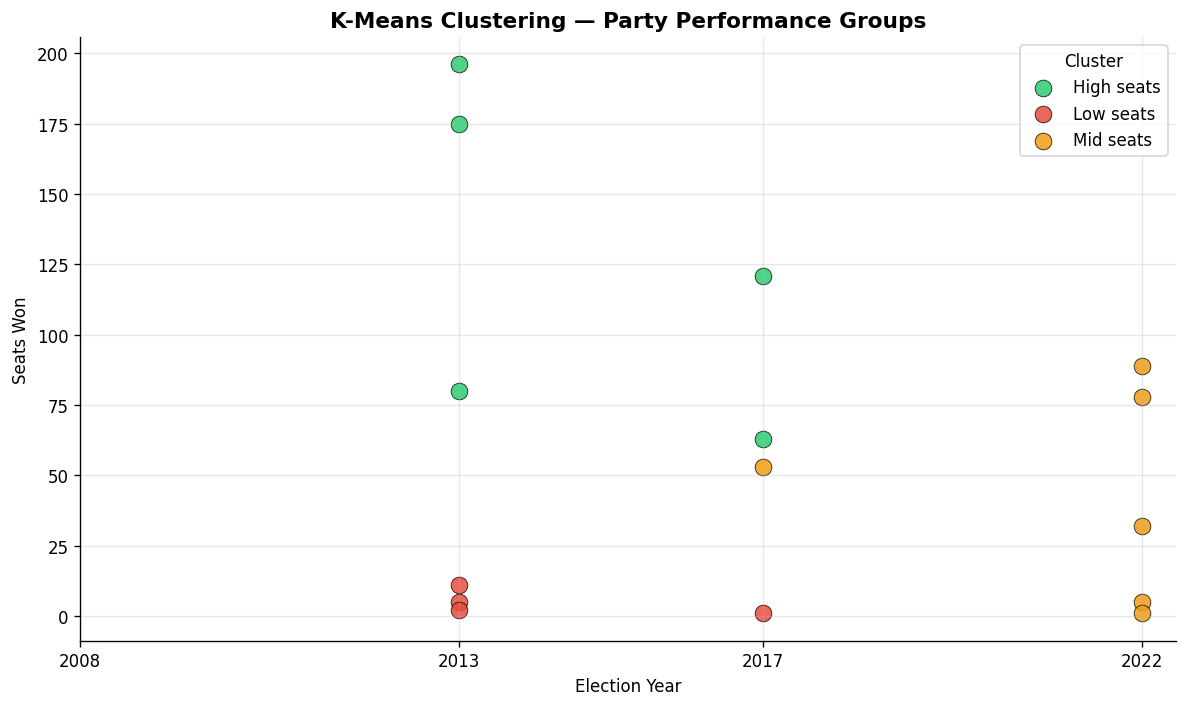

                                party_clean  year  total cluster_label
                            Nepali Congress  2013    196    High seats
                                    CPN-UML  2013    175    High seats
                                    CPN-UML  2017    121    High seats
                            Nepali Congress  2022     89     Mid seats
                                CPN-Maoists  2013     80    High seats
                                    CPN-UML  2022     78     Mid seats
                            Nepali Congress  2017     63    High seats
                                CPN-Maoists  2017     53     Mid seats
                                CPN-Maoists  2022     32     Mid seats
              Tarai Madhes Loktantrik Party  2013     11     Low seats
Communist Party of Nepal (Marxist Leninist)  2013      5     Low seats
                               Independents  2022      5     Mid seats


In [17]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
ml_df["cluster"] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, ml_df["cluster"])
print(f"Silhouette score (k={K}): {sil:.3f}  — higher is better; >0.3 is reasonable for small data")

cluster_means = ml_df.groupby("cluster")["total"].mean().sort_values()
label_map = {cluster_means.index[0]: "Low seats",
             cluster_means.index[1]: "Mid seats",
             cluster_means.index[2]: "High seats"}
ml_df["cluster_label"] = ml_df["cluster"].map(label_map)

colors = {"Low seats": "#e74c3c", "Mid seats": "#f39c12", "High seats": "#2ecc71"}
fig, ax = plt.subplots(figsize=(10, 6))
for label, group in ml_df.groupby("cluster_label"):
    ax.scatter(group["year"], group["total"], label=label, color=colors[label],
               s=100, edgecolors="black", linewidths=0.5, alpha=0.85)
ax.set_title("K-Means Clustering — Party Performance Groups", fontsize=13, fontweight="bold")
ax.set_xlabel("Election Year"); ax.set_ylabel("Seats Won")
ax.set_xticks([2008, 2013, 2017, 2022]); ax.legend(title="Cluster")
plt.tight_layout(); plt.show()

print(ml_df[["party_clean", "year", "total", "cluster_label"]]
      .sort_values("total", ascending=False).head(12).to_string(index=False))

# Summary Outcome: 

In [19]:
print("=" * 65)
print("  MODEL RESULTS SUMMARY")
print("=" * 65)

rmse_m, rmse_s = cv_rmse.mean(), cv_rmse.std()
r2_m,   r2_s   = cv_r2.mean(),   cv_r2.std()
acc_m,  acc_s  = cv_acc.mean(),  cv_acc.std()
auc_m,  auc_s  = cv_auc.mean(),  cv_auc.std()
f1_m,   f1_s   = cv_f1.mean(),   cv_f1.std()

print(f"  LINEAR REGRESSION (5-fold CV)")
print(f"    RMSE  : {rmse_m:.2f} +/- {rmse_s:.2f} seats")
print(f"    R2    : {r2_m:.3f} +/- {r2_s:.3f}")
print()
print(f"  LOGISTIC REGRESSION (5-fold stratified CV)")
print(f"    Accuracy : {acc_m:.3f} +/- {acc_s:.3f}")
print(f"    ROC-AUC  : {auc_m:.3f} +/- {auc_s:.3f}")
print(f"    F1 (wtd) : {f1_m:.3f} +/- {f1_s:.3f}")
print()
print(f"  K-MEANS CLUSTERING (k=3)")
print(f"    Silhouette score : {sil:.3f}")

print(ml_df.groupby("cluster_label")["total"]
      .agg(["mean", "count"])
      .rename(columns={"mean": "Avg Seats", "count": "Parties"})
      .round(1).to_string())
print()

print("=" * 65)


  MODEL RESULTS SUMMARY
  LINEAR REGRESSION (5-fold CV)
    RMSE  : 51.35 +/- 29.85 seats
    R2    : -0.572 +/- 1.152

  LOGISTIC REGRESSION (5-fold stratified CV)
    Accuracy : 0.933 +/- 0.133
    ROC-AUC  : 0.900 +/- 0.200
    F1 (wtd) : 0.933 +/- 0.133

  K-MEANS CLUSTERING (k=3)
    Silhouette score : 0.460
               Avg Seats  Parties
cluster_label                    
High seats         127.0        5
Low seats            4.8        4
Mid seats           43.0        6



In [21]:
# ── 8.1  Retrain on Full Historical Data ─────────────────────────────────────
# Re-fit both pipelines on ALL available rows (no hold-out).
# The scaler inside each Pipeline refits automatically on the full set.

reg_pipeline.fit(X_reg, y_reg)
clf_pipeline.fit(X_clf, y_clf)

print("Linear Regression  — retrained on", len(X_reg), "rows")
print("Logistic Regression — retrained on", len(X_clf), "rows")
print()
print("Note: from this point forward, metrics quoted above no longer apply.")
print("      The models below are optimised for forecasting, not evaluation.")

Linear Regression  — retrained on 15 rows
Logistic Regression — retrained on 15 rows

Note: from this point forward, metrics quoted above no longer apply.
      The models below are optimised for forecasting, not evaluation.


In [22]:
# ── 8.2  Build Future Feature Matrix ─────────────────────────────────────────
# For each party that contested in 2022, treat their 2022 seat count as
# prev_total and set year = 2029 (next scheduled election cycle).

future = (
    ml_df[ml_df["year"] == 2022][["party_clean", "party_encoded", "total"]]
    .copy()
    .reset_index(drop=True)
)
future["year"]       = 2029
future["prev_total"] = future["total"]   # 2022 result → lag feature for 2029
future = future.rename(columns={"total": "seats_2022"})

FEATURES = ["party_encoded", "year", "prev_total"]
X_future = future[FEATURES].values

print("Parties included in 2029 forecast:")
print(future[["party_clean", "seats_2022"]].to_string(index=False))

Parties included in 2029 forecast:
        party_clean  seats_2022
        CPN-Maoists          32
            CPN-UML          78
       Independents           5
    Nepali Congress          89
Rastriya Janamorcha           1


In [23]:
# ── 8.3  Predicted Seats — Linear Regression ─────────────────────────────────

future["predicted_seats"] = reg_pipeline.predict(X_future).round().astype(int)

# Clip to plausible range: seats can't be negative or exceed total parliament seats
# Nepal's House of Representatives has 275 seats
future["predicted_seats"] = future["predicted_seats"].clip(lower=0, upper=275)

# Seat delta vs 2022
future["seat_change"] = future["predicted_seats"] - future["seats_2022"]

print("── 2029 Seat Forecast (Linear Regression) ──")
print(
    future[["party_clean", "seats_2022", "predicted_seats", "seat_change"]]
    .sort_values("predicted_seats", ascending=False)
    .to_string(index=False)
)

── 2029 Seat Forecast (Linear Regression) ──
        party_clean  seats_2022  predicted_seats  seat_change
    Nepali Congress          89               37          -52
            CPN-UML          78               32          -46
        CPN-Maoists          32               10          -22
       Independents           5                0           -5
Rastriya Janamorcha           1                0           -1


In [24]:
# ── 8.4  Predicted Popularity — Logistic Regression ──────────────────────────

future["will_be_popular"]    = clf_pipeline.predict(X_future)
future["popularity_prob"]    = clf_pipeline.predict_proba(X_future)[:, 1].round(3)
future["popularity_label"]   = future["will_be_popular"].map({1: "Popular 🟢", 0: "Not Popular 🔴"})

print("── 2029 Popularity Forecast (Logistic Regression) ──")
print(
    future[["party_clean", "predicted_seats", "popularity_prob", "popularity_label"]]
    .sort_values("popularity_prob", ascending=False)
    .to_string(index=False)
)
print()
print("popularity_prob = probability of performing above the 2029 field average")

── 2029 Popularity Forecast (Logistic Regression) ──
        party_clean  predicted_seats  popularity_prob popularity_label
            CPN-UML               32            0.909        Popular 🟢
        CPN-Maoists               10            0.839        Popular 🟢
    Nepali Congress               37            0.808        Popular 🟢
       Independents                0            0.490    Not Popular 🔴
Rastriya Janamorcha                0            0.296    Not Popular 🔴

popularity_prob = probability of performing above the 2029 field average


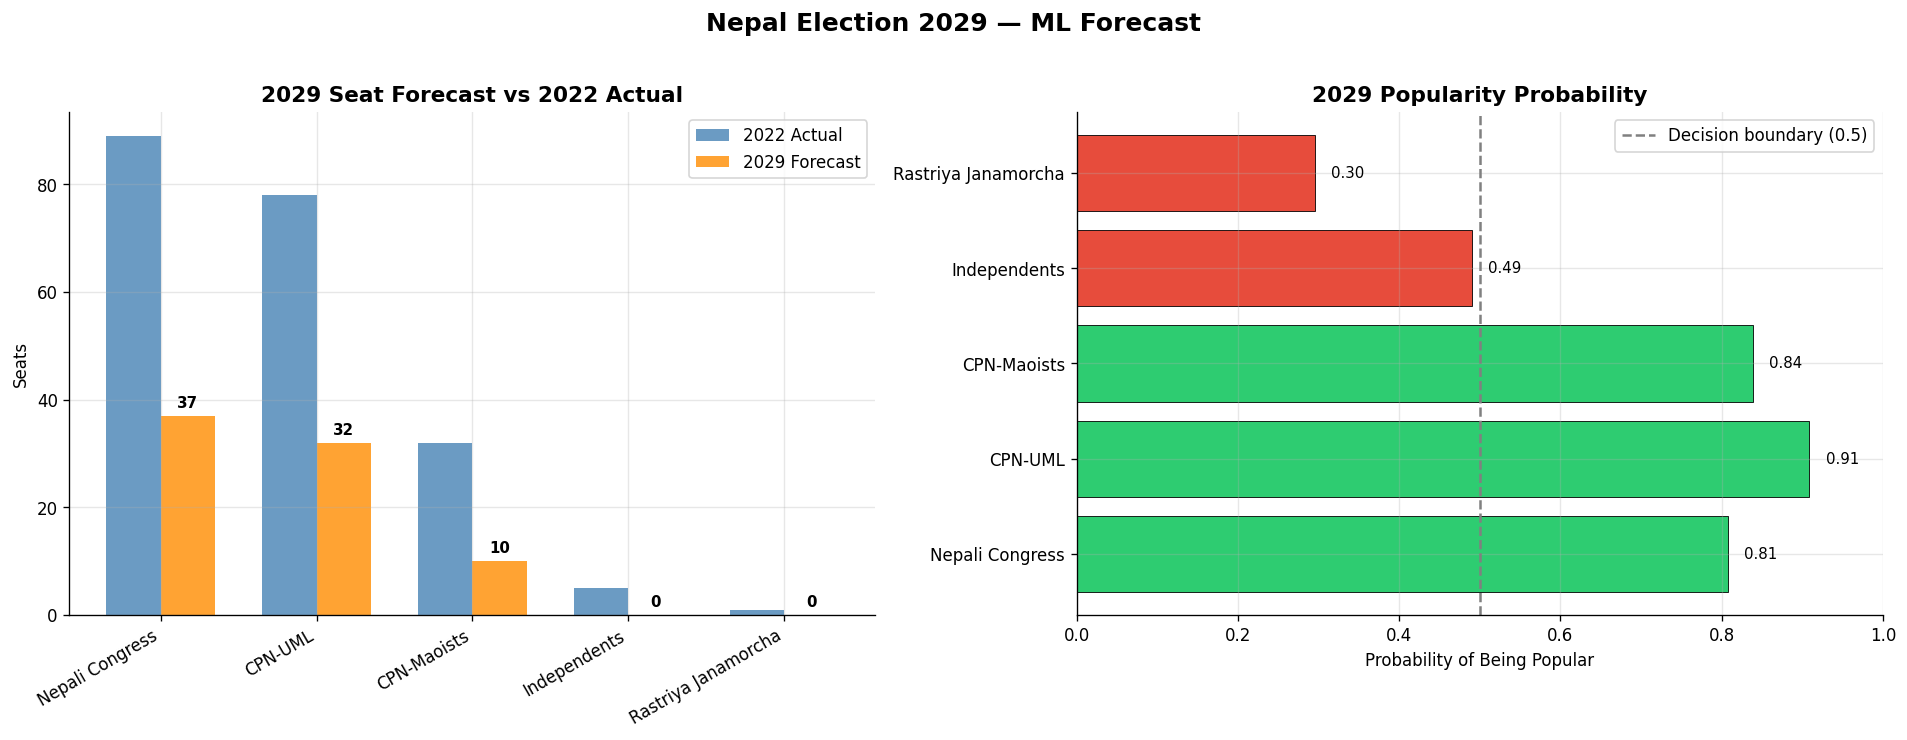


── Final Forecast Summary ──
              Party  2022 Seats  2029 Forecast  Δ Seats    Popularity
    Nepali Congress          89             37      -52     Popular 🟢
            CPN-UML          78             32      -46     Popular 🟢
        CPN-Maoists          32             10      -22     Popular 🟢
       Independents           5              0       -5 Not Popular 🔴
Rastriya Janamorcha           1              0       -1 Not Popular 🔴


In [25]:
# ── 8.5  Visualise Forecast ───────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
forecast_sorted = future.sort_values("predicted_seats", ascending=False)

# ── Plot A: Predicted seats vs 2022 actual ───────────────────────────────────
x     = np.arange(len(forecast_sorted))
width = 0.35

bars_actual = axes[0].bar(x - width/2, forecast_sorted["seats_2022"],
                           width, label="2022 Actual", color="steelblue",   alpha=0.8)
bars_pred   = axes[0].bar(x + width/2, forecast_sorted["predicted_seats"],
                           width, label="2029 Forecast", color="darkorange", alpha=0.8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(forecast_sorted["party_clean"], rotation=30, ha="right")
axes[0].set_ylabel("Seats")
axes[0].set_title("2029 Seat Forecast vs 2022 Actual", fontsize=13, fontweight="bold")
axes[0].legend()

# Annotate bar tops
for bar in bars_pred:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 str(int(bar.get_height())),
                 ha="center", va="bottom", fontsize=9, fontweight="bold")

# ── Plot B: Popularity probability ───────────────────────────────────────────
colors = ["#2ecc71" if p >= 0.5 else "#e74c3c" for p in forecast_sorted["popularity_prob"]]
axes[1].barh(forecast_sorted["party_clean"], forecast_sorted["popularity_prob"],
             color=colors, edgecolor="black", linewidth=0.5)
axes[1].axvline(0.5, color="gray", linestyle="--", label="Decision boundary (0.5)")
axes[1].set_xlabel("Probability of Being Popular")
axes[1].set_title("2029 Popularity Probability", fontsize=13, fontweight="bold")
axes[1].set_xlim(0, 1)
axes[1].legend()

for i, (prob, label) in enumerate(zip(forecast_sorted["popularity_prob"],
                                       forecast_sorted["popularity_label"])):
    axes[1].text(prob + 0.02, i, f"{prob:.2f}", va="center", fontsize=9)

plt.suptitle("Nepal Election 2029 — ML Forecast", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Final summary table ───────────────────────────────────────────────────────
print("\n── Final Forecast Summary ──")
print(
    future[["party_clean", "seats_2022", "predicted_seats", "seat_change", "popularity_label"]]
    .sort_values("predicted_seats", ascending=False)
    .rename(columns={
        "party_clean":      "Party",
        "seats_2022":       "2022 Seats",
        "predicted_seats":  "2029 Forecast",
        "seat_change":      "Δ Seats",
        "popularity_label": "Popularity",
    })
    .to_string(index=False)
)